In [1]:
import numpy as np
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor

In [2]:
# Set the same seed for both
seed = 42

# For statsmodels
np.random.seed(seed) 

# For PyMC-extras
rng = np.random.default_rng(seed)

Same random generated data

In [3]:
# Example parameters
n_obs = 100
endog = np.random.normal(size=(n_obs, 2))  
exog = np.random.normal(size=(n_obs, 2)) 

In [4]:
mod = DynamicFactor(endog, k_factors=1, factor_order=1, error_order=1, exog=exog)

In [5]:
T = mod.ssm['transition']
Z = mod.ssm['design']
R = mod.ssm['selection']
Q = mod.ssm['state_cov']
H = mod.ssm['obs_cov']
c = mod.ssm['state_intercept']
d = mod.ssm['obs_intercept']

Same shock for both stats and pymc

In [6]:
state_shocks = rng.multivariate_normal(np.zeros(Q.shape[0]), Q, size=n_obs)
measurement_shocks = rng.multivariate_normal(np.zeros(H.shape[0]), H, size=n_obs)

In [7]:
# Overwrite initialization to custom values
mod.ssm.initialize_known(
    constant=np.zeros((3,)),  # x0 (size = k_states)
    stationary_cov=np.zeros((3,3)) # P0
)

In [8]:
print(mod.param_names)


params = [0.9, 0.8,    # factor loadings
          0.3, 0.5, 1, 2,       # betas
          0.7, 0.6,    # error variances (sigma²)
          0.5,         # factor AR coefficient  
          0.4, 0.3]    # error AR coefficients

# Simulate trajectory
simulated_data = mod.simulate(params, n_obs, exog=exog, measurement_shocks=measurement_shocks, state_shocks=state_shocks, initial_state=np.zeros((3,)), random_state=seed)
print(simulated_data[:5])

['loading.f1.y1', 'loading.f1.y2', 'beta.x1.y1', 'beta.x2.y1', 'beta.x1.y2', 'beta.x2.y2', 'sigma2.y1', 'sigma2.y2', 'L1.f1.f1', 'L1.e(y1).e(y1)', 'L1.e(y2).e(y2)']
[[ 0.38772847  1.47935641]
 [ 1.12606177  3.43442901]
 [ 0.1014176  -2.37898084]
 [ 1.01827538  2.08204879]
 [ 1.61657643  7.80779634]]


In [9]:
# Update the model's state-space representation with the parameters
mod.update(params)

# Access state-space system matrices
print("Design matrix (Z):\n", mod.ssm['design'])
print("Transition matrix (T):\n", mod.ssm['transition'])
print("Selection matrix (R):\n", mod.ssm['selection'])
print("State covariance matrix (Q):\n", mod.ssm['state_cov'])
print("Observation intercept (d):\n", mod.ssm['obs_intercept'])
print("State intercept (c):\n", mod.ssm['state_intercept'])

Design matrix (Z):
 [[0.9 1.  0. ]
 [0.8 0.  1. ]]
Transition matrix (T):
 [[0.5 0.  0. ]
 [0.  0.4 0. ]
 [0.  0.  0.3]]
Selection matrix (R):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
State covariance matrix (Q):
 [[1.  0.  0. ]
 [0.  0.7 0. ]
 [0.  0.  0.6]]
Observation intercept (d):
 [[ 3.87728471e-01  8.51816399e-01 -8.82213330e-01  4.11403556e-01
   2.08088005e+00  7.39049973e-01  6.11896155e-01  2.84903837e-01
  -3.50256868e-01 -1.04671995e-01 -2.39235026e-01 -6.00479878e-01
   4.02895739e-01 -5.19588383e-01  1.25207762e-01 -1.10880695e-01
  -3.12128622e-01  9.60142738e-01 -5.14315619e-01  2.27680728e-01
  -2.95124442e-01  5.84373781e-01 -5.27339540e-01 -4.69148210e-01
   7.32127128e-01  8.06657872e-02  1.15287949e+00 -6.97928026e-01
   2.62386119e-02  5.20462855e-01 -3.07841820e-01 -1.48457402e+00
  -6.99662036e-01 -2.25347298e-01 -6.66430574e-02 -2.85549089e-01
   3.54065656e-01 -6.34008582e-02 -2.40390530e-01 -1.71716173e-01
   3.65120541e-01 -1.43102705e-01 -3.36133887e-01  2.48

In [10]:
from pymc_extras.statespace.models.DFM import BayesianDynamicFactor

In [11]:
# Create DFM Statespace Model
dfm_mod = BayesianDynamicFactor(
    k_factors=1,
    factor_order=1,
    k_endog=2,
    error_order=1,
    error_var=False,
    k_exog=2,
    shared_exog_states=False,
    exog_innovations=False,
    error_cov_type="diagonal",
    measurement_error=False,
    verbose=True
)

                                     Model Requirements                                      
                                                                                             
  Variable          Shape       Constraints                                      Dimensions  
 ─────────────────────────────────────────────────────────────────────────────────────────── 
  x0                (7,)                                                         ('state',)  
  P0                (7, 7)      Positive Semi-definite               ('state', 'state_aux')  
  factor_loadings   (2, 1)                                     ('observed_state', 'factor')  
  factor_ar         (1, 1)                                             ('factor', 'lag_ar')  
  error_ar          (2, 1)                               ('observed_state', 'error_lag_ar')  
  error_sigma       (2,)        Positive                                ('observed_state',)  
  beta              (4,)                                               ('exogenous_state',)  
                                                                                             
  exog_data         (None, 2)   pm.Data                         ('time', 'exogenous_state')  
                                                                                             
   These parameters should be assigned priors inside a PyMC model block before calling the   
                               build_statespace_graph method.                                

In [12]:
import pytensor

from pymc_extras.statespace.utils.constants import (
    MATRIX_NAMES,
    SHORT_NAME_TO_LONG,
)
def unpack_statespace(ssm):
    return [ssm[SHORT_NAME_TO_LONG[x]] for x in MATRIX_NAMES]

In [26]:
def unpack_symbolic_matrices_with_params(mod, param_dict, data_dict=None, mode="FAST_COMPILE"):
    inputs = list(mod._name_to_variable.values())
    if data_dict is not None:
        inputs += list(mod._name_to_data.values())
    else:
        data_dict = {}

    f_matrices = pytensor.function(
        inputs,
        unpack_statespace(mod.ssm),
        on_unused_input="raise",
        mode=mode,
    )

    x0, P0, c, d, T, Z, R, H, Q = f_matrices(**param_dict, **data_dict)

    return x0, P0, c, d, T, Z, R, H, Q


def simulate_from_numpy_model(mod, rng, param_dict, data_dict=None, steps=100, state_shocks=None, measurement_shocks=None):
    """
    Helper function to visualize the components outside of a PyMC model context

    Modified version in order to take as input state_shocks and measurement_shocks otherwise 
    the random quantities between stats and pymc will be different leading to different obs variables
    """
    x0, P0, c, d, T, Z, R, H, Q = unpack_symbolic_matrices_with_params(mod, param_dict, data_dict)
    k_endog = mod.k_endog
    k_states = mod.k_states
    k_posdef = mod.k_posdef

    x = np.zeros((steps, k_states))
    y = np.zeros((steps, k_endog))

    x[0] = x0
    y[0] = (Z @ x0).squeeze() if Z.ndim == 2 else (Z[0] @ x0).squeeze()

    if not np.allclose(H, 0):
        y[0] += rng.multivariate_normal(mean=np.zeros(1), cov=H).squeeze()

    for t in range(1, steps):
        if k_posdef > 0:
            #innov = R @ rng.multivariate_normal(mean=np.zeros(k_posdef), cov=Q)
            shock = np.concatenate((state_shocks[t - 1], np.zeros(4)), axis=0)
            innov = R @ shock
        else:
            innov = 0

        if not np.allclose(H, 0):
           error = measurement_shocks[t - 1]
        else:
            error = 0

        x[t] = c + T @ x[t - 1] + innov
        if Z.ndim == 2:
            y[t] = (d + Z @ x[t] + error).squeeze()
        else:
            y[t] = (d + Z[t] @ x[t] + error).squeeze()

    return x, y.squeeze()


In [27]:
dfm_mod.param_info

{'x0': {'shape': (7,), 'constraints': None, 'dims': ('state',)},
 'P0': {'shape': (7, 7),
  'constraints': 'Positive Semi-definite',
  'dims': ('state', 'state_aux')},
 'factor_loadings': {'shape': (2, 1),
  'constraints': None,
  'dims': ('observed_state', 'factor')},
 'factor_ar': {'shape': (1, 1),
  'constraints': None,
  'dims': ('factor', 'lag_ar')},
 'error_ar': {'shape': (2, 1),
  'constraints': None,
  'dims': ('observed_state', 'error_lag_ar')},
 'error_sigma': {'shape': (2,),
  'constraints': 'Positive',
  'dims': ('observed_state',)},
 'beta': {'shape': (4,), 'constraints': None, 'dims': ('exogenous_state',)}}

In [28]:
# Create parameter dictionary matching only the expected parameters
expected_params = list(dfm_mod._name_to_variable.keys())
expected_data = list(dfm_mod._name_to_data.keys())

print("Expected parameters:", expected_params)
print("Expected data:", expected_data)

Expected parameters: ['x0', 'beta', 'P0', 'factor_loadings', 'factor_ar', 'error_ar', 'error_sigma']
Expected data: ['exog_data']


In [29]:
# Create parameter dictionary matching only the expected parameters
expected_params = list(dfm_mod._name_to_variable.keys())
expected_data = list(dfm_mod._name_to_data.keys())

print("Expected parameters:", expected_params)
print("Expected data:", expected_data)

# Build param_dict with only the parameters the model expects
param_dict = {}
data_dict = {}

# Add parameters based on what's actually expected
if "factor_loadings" in expected_params:
    param_dict["factor_loadings"] = np.array([[0.9], [0.8]])
if "factor_ar" in expected_params:
    param_dict["factor_ar"] = np.array([[0.5]])
if "error_ar" in expected_params:
    param_dict["error_ar"] = np.array([[0.4], [0.3]])
if "error_sigma" in expected_params:
    param_dict["error_sigma"] = np.array([np.sqrt(0.7), np.sqrt(0.6)])
if "P0" in expected_params:
    param_dict["P0"] = np.eye(dfm_mod.k_states)
if "x0" in expected_params:
    param_dict["x0"] = np.array([0.0, 0.0, 0.0])  # Initial state
if "beta" in expected_params:
    param_dict["beta"] = np.array([0.3, 0.5, 1, 2])
if "beta_sigma" in expected_params:
    param_dict["beta_sigma"] = np.array([np.sqrt(1), np.sqrt(2)])



# Add data based on what's expected
if "exog_data" in expected_data:
    data_dict["exog_data"] = exog

print("Final param_dict keys:", list(param_dict.keys()))
print("Final data_dict keys:", list(data_dict.keys()))

# Now try the simulation
x_traj, y_traj = simulate_from_numpy_model(dfm_mod, rng, param_dict, data_dict, steps=n_obs, state_shocks=state_shocks, measurement_shocks=measurement_shocks)

Expected parameters: ['x0', 'beta', 'P0', 'factor_loadings', 'factor_ar', 'error_ar', 'error_sigma']
Expected data: ['exog_data']
Final param_dict keys: ['factor_loadings', 'factor_ar', 'error_ar', 'error_sigma', 'P0', 'x0', 'beta']
Final data_dict keys: ['exog_data']


In [30]:
unpack_symbolic_matrices_with_params(dfm_mod, param_dict, data_dict)

(array([0. , 0. , 0. , 0.3, 0.5, 1. , 2. ]),
 array([[1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 1.]]),
 array([0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0.]),
 array([[0.5, 0. , 0. , 0. , 0. , 0. , 0. ],
        [0. , 0.4, 0. , 0. , 0. , 0. , 0. ],
        [0. , 0. , 0.3, 0. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 1. , 0. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 1. , 0. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 1. , 0. ],
        [0. , 0. , 0. , 0. , 0. , 0. , 1. ]]),
 array([[[ 0.9       ,  1.        ,  0.        , ...,  0.56078453,
           0.        ,  0.        ],
         [ 0.8       ,  0.        ,  1.        , ...,  0.        ,
           0.35778736,  0.56078453]],
 
        [[ 0.9       ,  1.        ,  0.        , ...,  1.05380205,
           0.        ,  0.        ],

In [31]:
print(simulated_data)

[[ 0.38772847  1.47935641]
 [ 1.12606177  3.43442901]
 [ 0.1014176  -2.37898084]
 [ 1.01827538  2.08204879]
 [ 1.61657643  7.80779634]
 [ 0.56632579  2.68848918]
 [-0.24782915  1.49258399]
 [ 0.64564645  1.5233293 ]
 [-0.78272215 -1.63087601]
 [-0.70639968 -0.85648432]
 [-0.21119921 -1.39495109]
 [ 1.34102087 -0.81339311]
 [ 0.64125066  1.91784037]
 [-0.50296364 -2.07643198]
 [ 0.71905364  1.1717548 ]
 [-0.41291649 -0.56592571]
 [-0.26632678 -1.21691611]
 [ 1.59406586  3.97526936]
 [ 0.37080535 -0.86545976]
 [ 0.24690582  1.06016918]
 [ 1.05993529  0.18250391]
 [-0.25267915  1.49245062]
 [-0.41826591 -1.77234454]
 [-0.72846396 -2.01210666]
 [ 0.43029536  2.30712276]
 [-0.89775715 -0.29486934]
 [ 1.28510484  4.30462036]
 [-0.068784   -1.92859898]
 [-0.25492272 -0.39834897]
 [-0.69637349  0.91145523]
 [-0.90501529 -1.57680204]
 [-1.18431416 -5.02314497]
 [-0.62127849 -2.67846026]
 [-1.37658518 -2.25119401]
 [-1.45719315 -1.41460786]
 [-1.30146171 -2.33348445]
 [-0.33878446  0.56776311]
 

In [32]:
print(y_traj)  

[[ 0.38772847  1.47935641]
 [ 1.12606177  3.43442901]
 [ 0.1014176  -2.37898084]
 [ 1.01827538  2.08204879]
 [ 1.61657643  7.80779634]
 [ 0.56632579  2.68848918]
 [-0.24782915  1.49258399]
 [ 0.64564645  1.5233293 ]
 [-0.78272215 -1.63087601]
 [-0.70639968 -0.85648432]
 [-0.21119921 -1.39495109]
 [ 1.34102087 -0.81339311]
 [ 0.64125066  1.91784037]
 [-0.50296364 -2.07643198]
 [ 0.71905364  1.1717548 ]
 [-0.41291649 -0.56592571]
 [-0.26632678 -1.21691611]
 [ 1.59406586  3.97526936]
 [ 0.37080535 -0.86545976]
 [ 0.24690582  1.06016918]
 [ 1.05993529  0.18250391]
 [-0.25267915  1.49245062]
 [-0.41826591 -1.77234454]
 [-0.72846396 -2.01210666]
 [ 0.43029536  2.30712276]
 [-0.89775715 -0.29486934]
 [ 1.28510484  4.30462036]
 [-0.068784   -1.92859898]
 [-0.25492272 -0.39834897]
 [-0.69637349  0.91145523]
 [-0.90501529 -1.57680204]
 [-1.18431416 -5.02314497]
 [-0.62127849 -2.67846026]
 [-1.37658518 -2.25119401]
 [-1.45719315 -1.41460786]
 [-1.30146171 -2.33348445]
 [-0.33878446  0.56776311]
 

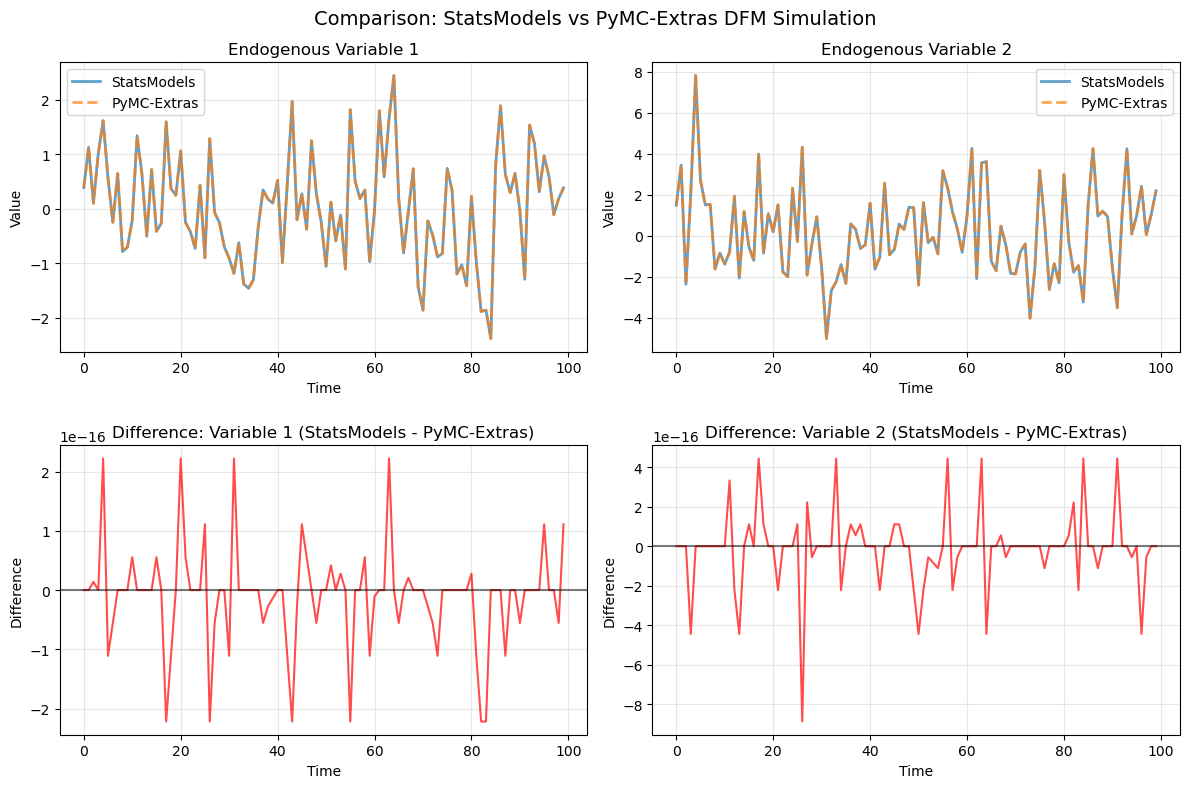

Summary Statistics:
Max absolute difference - Variable 1: 0.000000
Max absolute difference - Variable 2: 0.000000
Mean absolute difference - Variable 1: 0.000000
Mean absolute difference - Variable 2: 0.000000
Are they approximately equal? True


In [33]:
import matplotlib.pyplot as plt

# Create a comparison plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Comparison: StatsModels vs PyMC-Extras DFM Simulation', fontsize=14)

# Plot first endogenous variable
axes[0, 0].plot(simulated_data[:, 0], label='StatsModels', alpha=0.7, linewidth=2)
axes[0, 0].plot(y_traj[:, 0], label='PyMC-Extras', alpha=0.7, linewidth=2, linestyle='--')
axes[0, 0].set_title('Endogenous Variable 1')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot second endogenous variable
axes[0, 1].plot(simulated_data[:, 1], label='StatsModels', alpha=0.7, linewidth=2)
axes[0, 1].plot(y_traj[:, 1], label='PyMC-Extras', alpha=0.7, linewidth=2, linestyle='--')
axes[0, 1].set_title('Endogenous Variable 2')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot differences
diff1 = simulated_data[:, 0] - y_traj[:, 0]
diff2 = simulated_data[:, 1] - y_traj[:, 1]

axes[1, 0].plot(diff1, color='red', alpha=0.7)
axes[1, 0].set_title('Difference: Variable 1 (StatsModels - PyMC-Extras)')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Difference')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)

axes[1, 1].plot(diff2, color='red', alpha=0.7)
axes[1, 1].set_title('Difference: Variable 2 (StatsModels - PyMC-Extras)')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Difference')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print("=" * 50)
print(f"Max absolute difference - Variable 1: {np.max(np.abs(diff1)):.6f}")
print(f"Max absolute difference - Variable 2: {np.max(np.abs(diff2)):.6f}")
print(f"Mean absolute difference - Variable 1: {np.mean(np.abs(diff1)):.6f}")
print(f"Mean absolute difference - Variable 2: {np.mean(np.abs(diff2)):.6f}")
print(f"Are they approximately equal? {np.allclose(simulated_data, y_traj, rtol=1e-10, atol=1e-10)}")